# Exploratory analysis & results walkthrough

Real field data from the National Zoological Gardens, Dehiwala. This notebook uses the same modules as the command-line pipeline (`src/`), so its numbers match `python src/evaluate.py`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd, matplotlib.pyplot as plt
import config, preprocess, evaluate
pd.set_option("display.width", 140)

df = preprocess.run()
df.head()

reading /home/claude/stress-classifier-zoo/data/processed/animal_stress_data.csv
clean: kept 190/190 rows
rows=190  observation days=28  2026-04-01 -> 2026-05-25
class distribution:
 species         stress_label  
Asian Elephant  Stress_Absent     73
                Stress_Present    23
Toque Macaque   Stress_Absent     56
                Stress_Present    38
data-quality: 21 sessions where the meal ended after the keeper left (plausible, but check against field sheets)
data-quality: 0 sessions with proximity > keeper presence
wrote 190 rows -> /home/claude/stress-classifier-zoo/data/processed/model_ready.csv


,species,enclosure,date,session,keeper_arrival_time,keeper_departure_time,meal_start_time,meal_end_time,inter_meal_interval_min,diet_variety_score,...,keeper_departure_time_min,meal_start_time_min,meal_end_time_min,date_parsed,keeper_presence_min,meal_duration_min,keeper_arrival_to_meal_start_min,meal_ended_after_keeper_left,group_key,target
0,Asian Elephant,E1,4/1/2026,Morning,8:25,9:13,8:33,8:50,191,3,...,553.0,513.0,530.0,2026-04-01,48.0,17.0,8.0,0,2026-04-01,1
1,Asian Elephant,E1,4/3/2026,Afternoon,15:25,15:50,15:37,16:04,301,4,...,950.0,937.0,964.0,2026-04-03,25.0,27.0,12.0,1,2026-04-03,0
2,Asian Elephant,E1,4/5/2026,Morning,8:15,8:42,8:23,8:41,253,3,...,522.0,503.0,521.0,2026-04-05,27.0,18.0,8.0,0,2026-04-05,1
3,Asian Elephant,E2,4/7/2026,Afternoon,15:15,15:40,15:22,15:42,298,5,...,940.0,922.0,942.0,2026-04-07,25.0,20.0,7.0,1,2026-04-07,0
4,Asian Elephant,E2,4/9/2026,Morning,8:10,8:46,8:16,8:45,351,3,...,526.0,496.0,525.0,2026-04-09,36.0,29.0,6.0,0,2026-04-09,1


## 1. Dataset overview

In [2]:
print(df.groupby("species")["stress_label"].value_counts().unstack())
print("\nobservation days:", df.group_key.nunique(), "| sessions per day (mean):", round(len(df)/df.group_key.nunique(), 1))
print("stress-positive rate by species:\n", df.groupby("species")["target"].mean().round(3))
print("stress-positive rate by session:\n", df.groupby("session")["target"].mean().round(3))

stress_label    Stress_Absent  Stress_Present
species                                      
Asian Elephant             73              23
Toque Macaque              56              38

observation days: 28 | sessions per day (mean): 6.8
stress-positive rate by species:
 species
Asian Elephant    0.240
Toque Macaque     0.404
Name: target, dtype: float64
stress-positive rate by session:
 session
Afternoon    0.305
Morning      0.337
Name: target, dtype: float64


## 2. Is stress related to keeper-arrival timing? (distribution check)

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(axes, ["time_to_keeper_arrival_min", "inter_meal_interval_min", "activity_level"],
                          ["Time to keeper arrival (min)", "Inter-meal interval (min)", "Activity level"]):
    df.boxplot(column=col, by="stress_label", ax=ax, grid=False)
    ax.set_title(title); ax.set_xlabel("")
plt.suptitle("Feature distributions by stress label"); plt.tight_layout(); plt.show()
df.groupby("stress_label")[["time_to_keeper_arrival_min","inter_meal_interval_min","activity_level","location_changes","boundary_time_min"]].mean().round(2)

,time_to_keeper_arrival_min,inter_meal_interval_min,activity_level,location_changes,boundary_time_min
stress_label,,,,,
Stress_Absent,17.19,239.87,59.82,5.71,5.54
Stress_Present,9.92,218.30,60.03,6.57,7.66


## 3. Baseline vs proposed (day-grouped, stratified 5-fold CV on development days)

In [4]:
dev, test = evaluate.split_dev_test(df)
print(f"development: {len(dev)} sessions / {dev.group_key.nunique()} days | held-out test: {len(test)} sessions / {test.group_key.nunique()} days")
base = evaluate.cv_scores("RF", "baseline", dev)
prop = evaluate.cv_scores("RF", "proposed", dev)
print("Baseline:", evaluate.mean_std(base))
print("Proposed:", evaluate.mean_std(prop))
print(evaluate.paired_test(prop["f1"], base["f1"]))

development: 162 sessions / 24 days | held-out test: 28 sessions / 4 days


Baseline: {'f1': '0.313 ± 0.072', 'precision': '0.323 ± 0.071', 'recall': '0.311 ± 0.092', 'auc_roc': '0.540 ± 0.055'}
Proposed: {'f1': '0.691 ± 0.084', 'precision': '0.767 ± 0.080', 'recall': '0.635 ± 0.108', 'auc_roc': '0.854 ± 0.064'}
('paired t-test', np.float64(0.4780762305596562), np.float64(0.0033287471400389717))


## 4. Saved results from `python src/evaluate.py`


== cv_model_comparison


,model,f1,precision,recall,auc_roc
0,RF,0.691 ± 0.084,0.767 ± 0.080,0.635 ± 0.108,0.854 ± 0.064
1,SVM,0.529 ± 0.075,0.492 ± 0.083,0.593 ± 0.139,0.691 ± 0.067
2,GB,0.633 ± 0.141,0.657 ± 0.161,0.613 ± 0.129,0.826 ± 0.074
3,LR,0.511 ± 0.093,0.506 ± 0.187,0.558 ± 0.148,0.726 ± 0.101
4,MLP,0.461 ± 0.124,0.520 ± 0.145,0.425 ± 0.138,0.644 ± 0.071



== ablation_feature_sets


,feature_set,f1,precision,recall,auc_roc
0,movement_only,0.360 ± 0.097,0.381 ± 0.113,0.354 ± 0.108,0.567 ± 0.091
1,baseline,0.325 ± 0.093,0.343 ± 0.123,0.324 ± 0.104,0.542 ± 0.090
2,baseline+keeper_arrival,0.675 ± 0.132,0.725 ± 0.123,0.650 ± 0.172,0.849 ± 0.087
3,proposed,0.677 ± 0.147,0.771 ± 0.121,0.619 ± 0.179,0.844 ± 0.082
4,proposed+stereotypy,0.668 ± 0.132,0.784 ± 0.107,0.601 ± 0.166,0.858 ± 0.068



== test_set_results


,model,f1,precision,recall,auc_roc
0,baseline,0.471,0.5,0.444,0.538
1,proposed,0.500,1.0,0.333,0.807



== error_analysis


,group,stress_sessions,missed (false negatives),miss_rate,mean_time_to_keeper_arrival_min
0,species=Asian Elephant,19,6,0.316,7.8
1,species=Toque Macaque,33,13,0.394,10.1
2,session=Afternoon,23,9,0.391,8.4
3,session=Morning,29,10,0.345,9.9
4,enclosure=E1,7,3,0.429,8.0
5,enclosure=E2,12,3,0.250,7.8
6,enclosure=M1,16,8,0.500,12.6
7,enclosure=M2,17,5,0.294,7.7
8,ALL missed stress sessions,52,19,0.365,19.5
9,ALL correctly found stress sessions,52,0,0.000,3.4


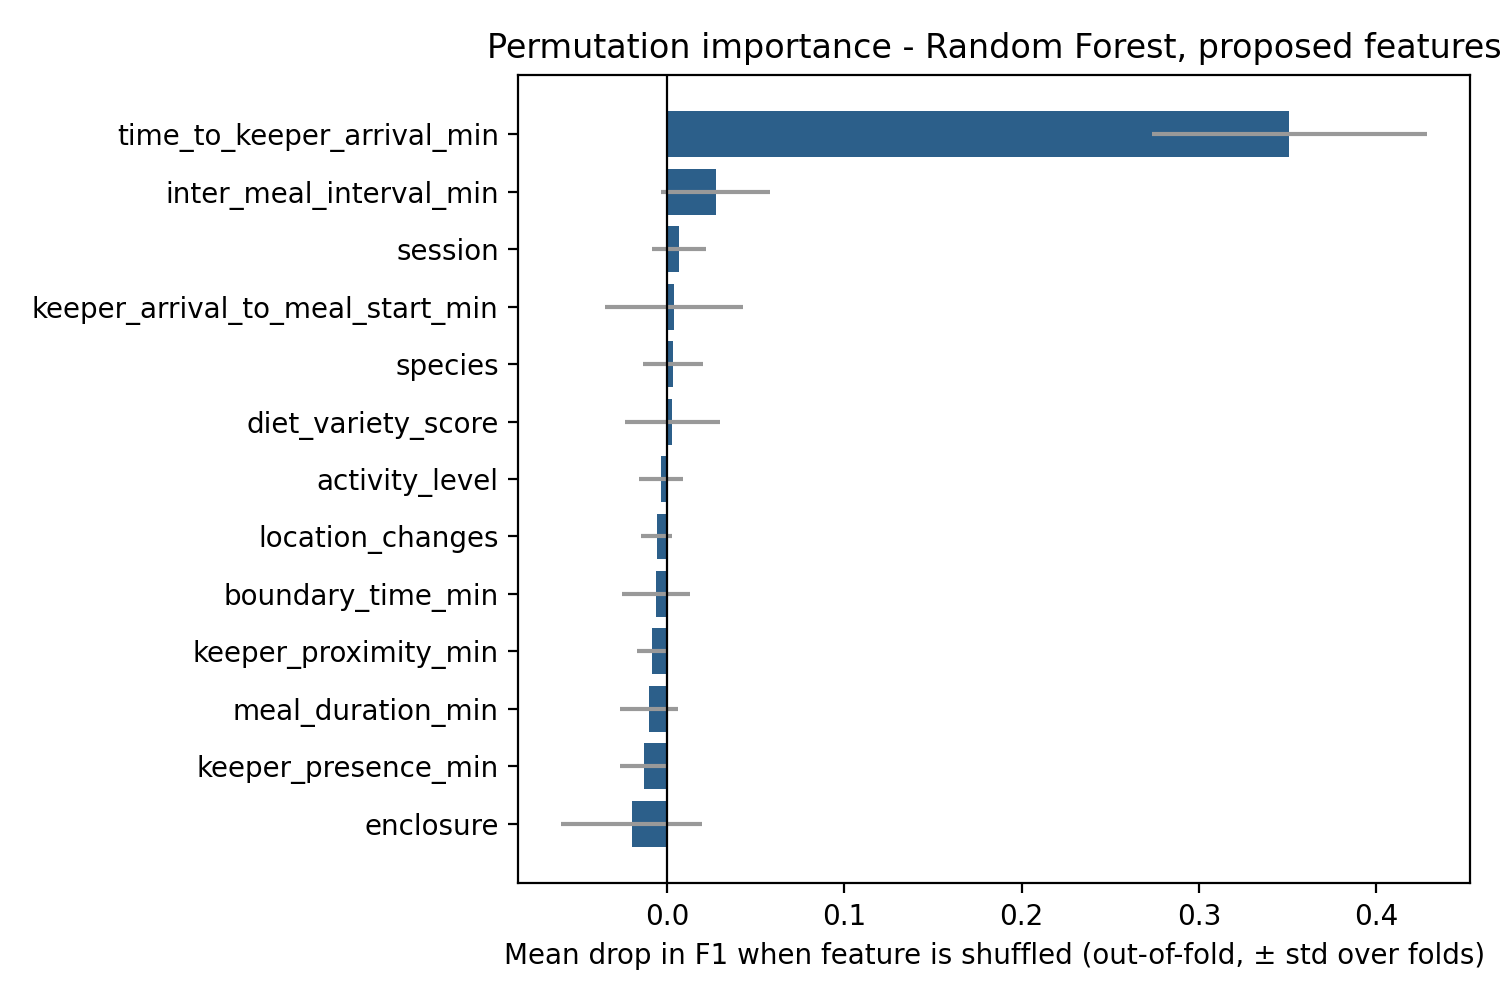

In [5]:
from IPython.display import display, Image
for name in ["cv_model_comparison", "ablation_feature_sets", "test_set_results", "error_analysis"]:
    print("\n==", name); display(pd.read_csv(config.RESULTS_DIR / f"{name}.csv"))
display(Image(str(config.RESULTS_DIR / "permutation_importance.png")))

**Reading the results.** The feature-set ablation shows that adding only `time_to_keeper_arrival_min` to the baseline recovers essentially all of the gain, so the effect is carried by keeper-arrival timing rather than by the full feeding/keeper feature set. The held-out test set is small (28 sessions), so cross-validation is the primary evidence.